In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 先用简单数字理解回撤 ───────────────────────────
equity = pd.Series([100, 110, 105, 120, 95, 108, 115])

rolling_max = equity.cummax()          # 历史最高点
drawdown    = (equity - rolling_max) / rolling_max * 100

print("资产值  :", equity.tolist())
print("历史高点:", rolling_max.tolist())
print("回撤%  :", drawdown.round(1).tolist())
print(f"最大回撤: {drawdown.min():.1f}%")

资产值  : [100, 110, 105, 120, 95, 108, 115]
历史高点: [100, 110, 110, 120, 120, 120, 120]
回撤%  : [0.0, 0.0, -4.5, 0.0, -20.8, -10.0, -4.2]
最大回撤: -20.8%


  指标                          6个月             3年


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


  策略收益率            +20.7 %  -16.7 %
  买入持有             +33.2 %  +27.4 %
  超额收益             -12.5 %  -44.1 %
  夏普比率             1.9    -0.2  
  最大回撤             -6.7 %  -39.4 %
  胜率               +100.0 %  +26.1 %
  交易次数             3 次  47 次


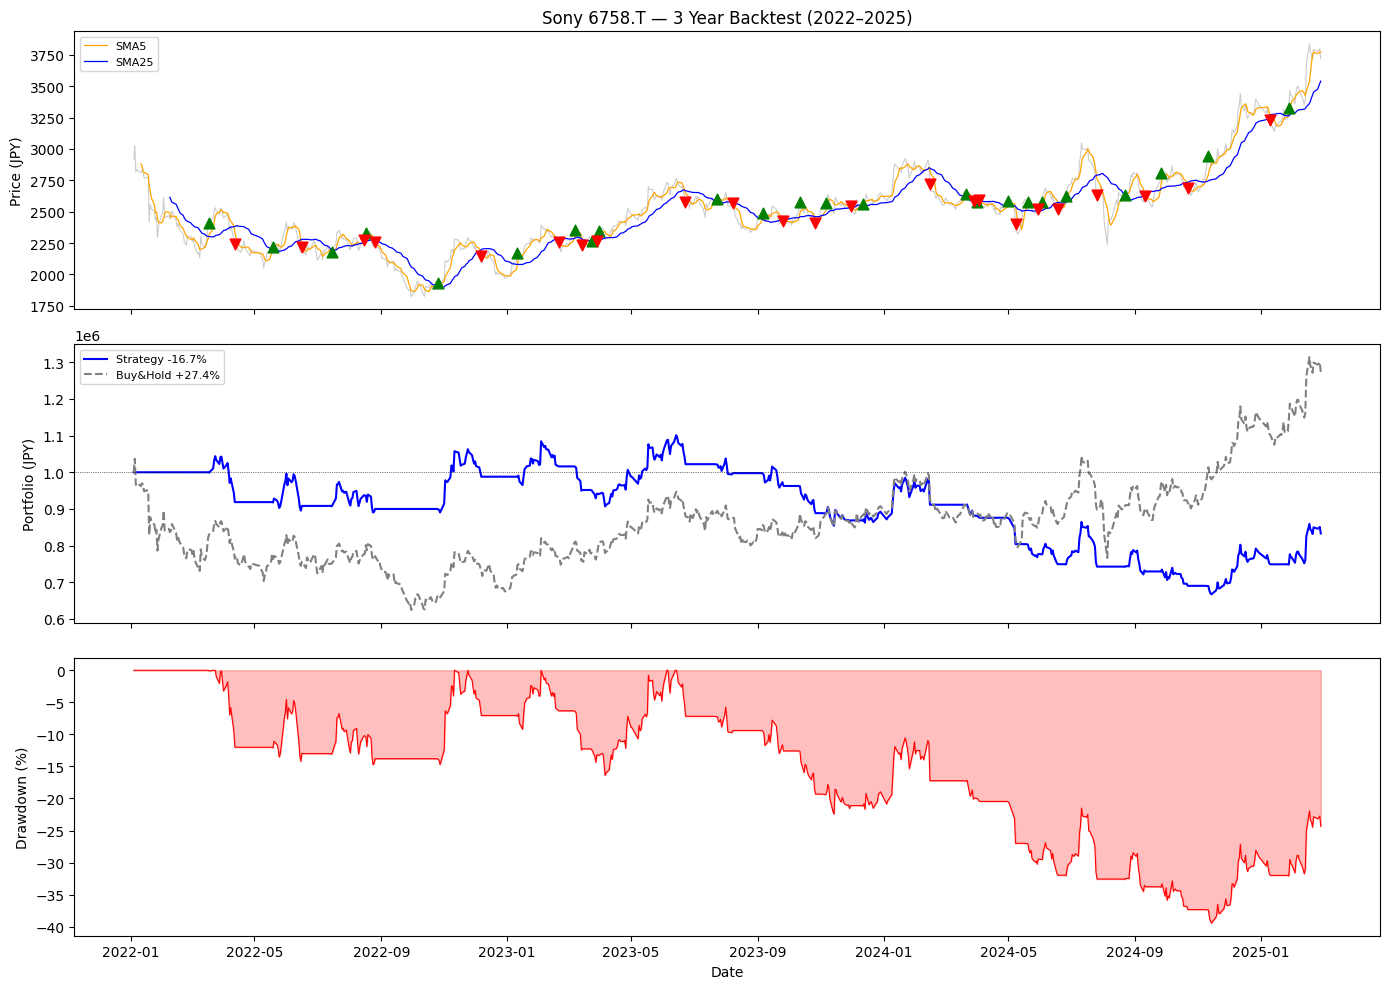

In [2]:
def backtest(ticker, start, end,
             fast=5, slow=25,
             commission=0.00055, slippage=0.0005,
             initial_cash=1_000_000):
    """
    通用回测函数，返回绩效字典和结果DataFrame
    """
    # 数据
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    df.columns = df.columns.droplevel(1) if df.columns.nlevels > 1 else df.columns
    df.dropna(inplace=True)

    # 信号
    df["fast"] = df["Close"].rolling(fast).mean()
    df["slow"] = df["Close"].rolling(slow).mean()
    prev = df["fast"].shift(1) - df["slow"].shift(1)
    curr = df["fast"] - df["slow"]
    df["signal"] = 0
    df.loc[(prev < 0) & (curr > 0), "signal"] =  1
    df.loc[(prev > 0) & (curr < 0), "signal"] = -1

    # 回测
    cash, shares, position = initial_cash, 0, False
    total_cost = 0
    records    = []

    for date, row in df.iterrows():
        price = float(row["Close"])
        sig   = int(row["signal"])
        action = "-"

        if sig == 1 and not position:
            buy_price  = price * (1 + slippage)
            shares     = int(cash / buy_price)
            cost       = shares * buy_price * commission
            cash      -= shares * buy_price + cost
            total_cost += cost
            position   = True
            action     = "BUY"

        elif sig == -1 and position:
            sell_price  = price * (1 - slippage)
            cost        = shares * sell_price * commission
            cash       += shares * sell_price - cost
            total_cost += cost
            shares      = 0
            position    = False
            action      = "SELL"

        records.append({
            "date"  : date,
            "price" : price,
            "action": action,
            "total" : cash + shares * price,
        })

    result = pd.DataFrame(records).set_index("date")

    # 回撤计算
    rolling_max  = result["total"].cummax()
    drawdown     = (result["total"] - rolling_max) / rolling_max
    max_dd       = drawdown.min() * 100

    # 夏普比率
    daily_ret    = result["total"].pct_change().dropna()
    rf_daily     = 0.001 / 252
    sharpe       = ((daily_ret - rf_daily).mean() /
                    (daily_ret - rf_daily).std()) * np.sqrt(252)

    # 胜率（每笔买入→卖出的盈亏）
    trades       = result[result["action"].isin(["BUY","SELL"])]
    buys         = trades[trades["action"] == "BUY"]["total"].values
    sells        = trades[trades["action"] == "SELL"]["total"].values
    n_complete   = min(len(buys), len(sells))
    win_rate     = (np.sum(sells[:n_complete] > buys[:n_complete])
                    / n_complete * 100) if n_complete > 0 else 0

    strategy_ret = (result["total"].iloc[-1] / initial_cash - 1) * 100
    buyhold_ret  = (df["Close"].iloc[-1] / df["Close"].iloc[0] - 1) * 100

    metrics = {
        "ticker"      : ticker,
        "period"      : f"{start} ~ {end}",
        "strategy_ret": strategy_ret,
        "buyhold_ret" : buyhold_ret,
        "alpha"       : strategy_ret - buyhold_ret,
        "sharpe"      : sharpe,
        "max_dd"      : max_dd,
        "win_rate"    : win_rate,
        "n_trades"    : len(trades),
        "total_cost"  : total_cost,
    }
    return metrics, result, df, drawdown


# ── 第三步：3年 vs 6个月 对比 ──────────────────────
print("=" * 52)
print(f"  {'指标':<16} {'6个月':>14} {'3年':>14}")
print("=" * 52)

m6, r6, d6, dd6 = backtest("6758.T", "2024-09-01", "2025-03-01")
m3, r3, d3, dd3 = backtest("6758.T", "2022-01-01", "2025-03-01")

metrics_to_show = [
    ("策略收益率",  "strategy_ret", "%"),
    ("买入持有",    "buyhold_ret",  "%"),
    ("超额收益",    "alpha",        "%"),
    ("夏普比率",    "sharpe",       ""),
    ("最大回撤",    "max_dd",       "%"),
    ("胜率",        "win_rate",     "%"),
    ("交易次数",    "n_trades",     "次"),
]

for label, key, unit in metrics_to_show:
    v6 = m6[key]
    v3 = m3[key]
    fmt = ".1f" if unit in ("%","") else ".0f"
    sign = "+" if unit == "%" and v6 > 0 else ""
    print(f"  {label:<16} {sign}{v6:{fmt}}{unit:>2}  {'+' if unit=='%' and v3>0 else ''}{v3:{fmt}}{unit:>2}")

print("=" * 52)


# ── 第四步：3年资产曲线 + 回撤图 ──────────────────
buyhold3 = 1_000_000 * (d3["Close"] / d3["Close"].iloc[0])

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 上：股价 + 均线
axes[0].plot(d3["Close"], color="gray", alpha=0.4, linewidth=0.8)
axes[0].plot(d3["fast"],  color="orange", linewidth=0.9, label="SMA5")
axes[0].plot(d3["slow"],  color="blue",   linewidth=0.9, label="SMA25")
buys3  = r3[r3["action"] == "BUY"]
sells3 = r3[r3["action"] == "SELL"]
axes[0].scatter(buys3.index,  buys3["price"]  * 0.995,
                marker="^", color="green", s=60, zorder=5)
axes[0].scatter(sells3.index, sells3["price"] * 1.005,
                marker="v", color="red",   s=60, zorder=5)
axes[0].set_ylabel("Price (JPY)")
axes[0].set_title("Sony 6758.T — 3 Year Backtest (2022–2025)")
axes[0].legend(fontsize=8)

# 中：资产曲线
axes[1].plot(r3.index, r3["total"],  color="blue", linewidth=1.5,
             label=f"Strategy {m3['strategy_ret']:+.1f}%")
axes[1].plot(buyhold3.index, buyhold3, color="gray", linewidth=1.5,
             linestyle="dashed", label=f"Buy&Hold {m3['buyhold_ret']:+.1f}%")
axes[1].axhline(1_000_000, color="black", linewidth=0.5, linestyle="dotted")
axes[1].set_ylabel("Portfolio (JPY)")
axes[1].legend(fontsize=8)

# 下：回撤
axes[2].fill_between(dd3.index, dd3 * 100, 0, color="red", alpha=0.25)
axes[2].plot(dd3.index, dd3 * 100, color="red", linewidth=0.8)
axes[2].set_ylabel("Drawdown (%)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()